## Cài đặt và Đăng nhập

In [1]:
!pip install -q transformers[torch] datasets pyvi accelerate huggingface_hub

from huggingface_hub import notebook_login
# Dán Token (quyền WRITE) từ Hugging Face vào đây
notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Chuẩn bị dữ liệu từ Hugging Face Hub

In [2]:
import pandas as pd
from datasets import load_dataset
from pyvi import ViTokenizer
from transformers import AutoTokenizer

# Tải dataset
dataset_id = "pqthinh232/vietnamese-restaurant-review-sentiment-dataset"
raw_datasets = load_dataset(dataset_id)

# Cấu hình Tokenizer
model_checkpoint = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Hàm tiền xử lý (Tách từ + Tokenize)
def preprocess_function(examples):
    # Tách từ tiếng Việt cho PhoBERT
    texts = [ViTokenizer.tokenize(str(text)) for text in examples["review"]]
    # Mã hóa văn bản thành tokens (giới hạn 256 tokens)
    return tokenizer(texts, truncation=True, padding="max_length", max_length=256)

print("--- Tokenizing for the dataset ---")
tokenized_datasets = raw_datasets.map(preprocess_function, batched=True, remove_columns=["review", "review_id"])

README.md:   0%|          | 0.00/570 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.30M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/669k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26170 [00:00<?, ? examples/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

--- Tokenizing for the dataset ---


Map:   0%|          | 0/26170 [00:00<?, ? examples/s]

Map:   0%|          | 0/3271 [00:00<?, ? examples/s]

Map:   0%|          | 0/3272 [00:00<?, ? examples/s]

## Tính toán Trọng số lớp (Class Weights)

In [3]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Lấy danh sách nhãn từ tập train để tính toán
labels = raw_datasets['train']['label']
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=labels)

# Chuyển thành tensor để đưa vào mô hình
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to("cuda")
print(f"Class Weights (Neg, Pos, Neu): {class_weights}")

Class Weights (Neg, Pos, Neu): [1.75378636 0.55040276 1.63144442]


## Xây dựng Custom Trainer (Để xử lý mất cân bằng)

In [4]:
from transformers import Trainer, AutoModelForSequenceClassification

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Sử dụng CrossEntropyLoss với trọng số lớp
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## Cấu hình Huấn luyện và Metrics

In [5]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import TrainingArguments

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Tính Accuracy tổng quát
    acc = accuracy_score(labels, predictions)

    # Tính F1-score (Dùng 'macro' để theo dõi sự công bằng giữa các nhãn trong lúc học)
    f1 = f1_score(labels, predictions, average='macro')

    return {
        'accuracy': acc,
        'f1': f1
    }

In [6]:
# Tên Repo nhóm muốn đặt trên Hugging Face
repo_name = "HCMUS-vietnamese-phobert-restaurant-sentiment-analysis"

training_args = TrainingArguments(
    output_dir=repo_name,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,              # Chỉ cần chạy 2 Epoch là quá đủ
    weight_decay=0.01,

    eval_strategy="steps",     # Đánh giá theo bước thay vì theo epoch
    eval_steps=200,                  # Cứ 500 bước (steps) thì chạy tập Validation một lần
    save_strategy="steps",           # Lưu mô hình theo bước
    save_steps=200,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=5,              # Chỉ giữ lại 2 checkpoint tốt nhất để đỡ tốn bộ nhớ Colab
    push_to_hub=True,
    logging_steps=100,
    report_to="none"
)

In [7]:
# Khởi tạo mô hình
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label={0: "Negative", 1: "Positive", 2: "Neutral"},
    label2id={"Negative": 0, "Positive": 1, "Neutral": 2}
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [8]:
# Khởi tạo Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

## Chạy Huấn luyện và Đánh giá tập Test

In [9]:
# 1. Bắt đầu huấn luyện
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
200,0.521765,0.406381,0.864262,0.832622
400,0.392225,0.366017,0.883828,0.848424
600,0.361147,0.540148,0.862733,0.797162
800,0.389344,0.338077,0.866096,0.840550
1000,0.352608,0.310094,0.875879,0.856586
1200,0.389178,0.337182,0.891776,0.860406
1400,0.335876,0.310033,0.886579,0.865574
1600,0.320299,0.291420,0.881688,0.863854
1800,0.289679,0.325063,0.897891,0.873608
2000,0.266915,0.307695,0.889330,0.869952


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3272, training_loss=0.33232514199534374, metrics={'train_runtime': 3349.1909, 'train_samples_per_second': 15.628, 'train_steps_per_second': 0.977, 'total_flos': 6885678141941760.0, 'train_loss': 0.33232514199534374, 'epoch': 2.0})

In [10]:
print(f"The best model: {trainer.state.best_model_checkpoint}")
print(f"The highest F1-score gained: {trainer.state.best_metric}")

The best model: HCMUS-vietnamese-phobert-restaurant-sentiment-analysis/checkpoint-3000
The highest F1-score gained: 0.8759258358506877


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Trích xuất lịch sử log
history = trainer.state.log_history

# 2. Chuyển thành DataFrame để dễ xử lý
df_history = pd.DataFrame(history)

# Vì Trainer lưu log train và log eval riêng biệt, ta cần gộp chúng lại theo Step
# Lọc bỏ các dòng thừa và chỉ giữ lại các cột quan trọng
df_plot = df_history.groupby('step').first().reset_index()

# 3. Lưu ra file CSV để làm "nguyên liệu" vẽ biểu đồ trong báo cáo sau này
df_plot.to_csv("training_history.csv", index=False)
print("✅ Đã lưu lịch sử huấn luyện vào file training_history.csv")

# Xem thử 5 dòng đầu
display(df_plot[['step', 'loss', 'eval_loss', 'eval_accuracy', 'eval_f1']].dropna().head())

✅ Đã lưu lịch sử huấn luyện vào file training_history.csv


,step,loss,eval_loss,eval_accuracy,eval_f1
1,200,0.521765,0.406381,0.864262,0.832622
3,400,0.392225,0.366017,0.883828,0.848424
5,600,0.361147,0.540148,0.862733,0.797162
7,800,0.389344,0.338077,0.866096,0.840550
9,1000,0.352608,0.310094,0.875879,0.856586


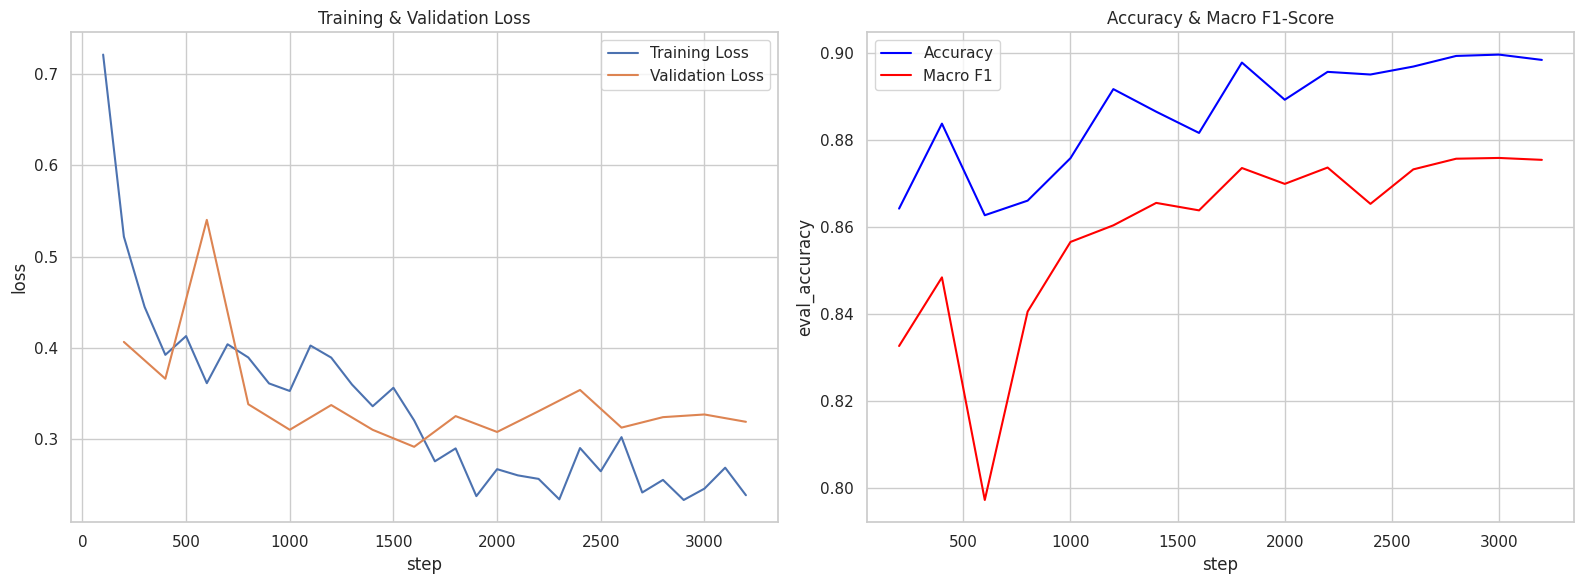

In [15]:
import seaborn as sns
sns.set_theme(style="whitegrid")

# Tạo khung hình
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Lọc bỏ các dòng không có dữ liệu evaluation để vẽ cho mượt
df_eval = df_plot.dropna(subset=['eval_f1'])

# Biểu đồ 1: Loss (Train vs Val)
sns.lineplot(data=df_plot.dropna(subset=['loss']), x='step', y='loss', ax=ax1, label='Training Loss')
sns.lineplot(data=df_eval, x='step', y='eval_loss', ax=ax1, label='Validation Loss')
ax1.set_title('Training & Validation Loss')

# Biểu đồ 2: Performance (Accuracy & F1)
sns.lineplot(data=df_eval, x='step', y='eval_accuracy', ax=ax2, label='Accuracy', color='blue')
sns.lineplot(data=df_eval, x='step', y='eval_f1', ax=ax2, label='Macro F1', color='red')
ax2.set_title('Accuracy & Macro F1-Score')

plt.tight_layout()
plt.show()

In [16]:
# 2. Đánh giá chi tiết trên tập Test (Dành cho báo cáo đồ án)
print("\n--- EVALUATION ON THE TEST SET ---")
test_results = trainer.evaluate(tokenized_datasets["test"])

# In bảng kết quả sạch đẹp
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 30)
for key, value in test_results.items():
    if key.startswith("eval_"):
        name = key.replace("eval_", "")
        print(f"{name:<15} | {value:.4f}")


--- EVALUATION ON THE TEST SET ---


Metric          | Value     
------------------------------
loss            | 0.3700
accuracy        | 0.8851
f1              | 0.8631
runtime         | 44.0857
samples_per_second | 74.2190
steps_per_second | 4.6500



--- ĐANG THỰC HIỆN DỰ ĐOÁN TRÊN TẬP TEST ---



        KẾT QUẢ MÔ HÌNH TRÊN TẬP TEST        
METRIC                    | VALUE          
---------------------------------------------
Test Loss                 | 0.3700
Test Accuracy             | 88.51%
Macro F1-Score            | 0.8631

BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):
                precision    recall  f1-score   support

  Tiêu cực (0)     0.9208    0.9164    0.9186       622
  Tích cực (1)     0.9487    0.9051    0.9264      1981
Trung tính (2)     0.6986    0.7967    0.7444       669

      accuracy                         0.8851      3272
     macro avg     0.8560    0.8727    0.8631      3272
  weighted avg     0.8922    0.8851    0.8877      3272



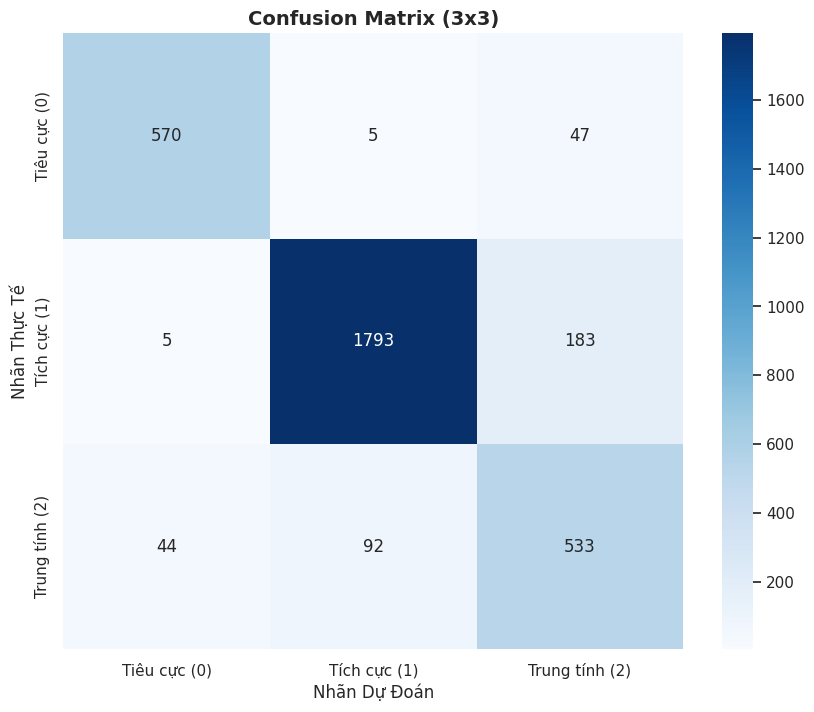


--- PERFORMANCE STATISTICS ---
runtime              | 44.4053
samples_per_second   | 73.6850
steps_per_second     | 4.6170


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 1. Thực hiện dự đoán trên tập Test
print("\n--- ĐANG THỰC HIỆN DỰ ĐOÁN TRÊN TẬP TEST ---")
predictions_output = trainer.predict(tokenized_datasets["test"])

# Lấy nhãn thực tế (y_true) và nhãn dự đoán (y_pred)
y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=-1)
test_metrics = predictions_output.metrics # Chứa loss và các thông số runtime

# 2. In bảng tóm tắt kết quả (Giống Hình 1)
print("\n" + "="*45)
print(f"{'KẾT QUẢ MÔ HÌNH TRÊN TẬP TEST':^45}")
print("="*45)
print(f"{'METRIC':<25} | {'VALUE':<15}")
print("-" * 45)
print(f"{'Test Loss':<25} | {test_metrics['test_loss']:.4f}")
print(f"{'Test Accuracy':<25} | {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"{'Macro F1-Score':<25} | {f1_score(y_true, y_pred, average='macro'):.4f}")
print("="*45)

# 3. In Báo cáo phân loại chi tiết (Giống Hình 1)
target_names = ["Tiêu cực (0)", "Tích cực (1)", "Trung tính (2)"]
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 4. Vẽ Ma trận nhầm lẫn (Giống Hình 2)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix (3x3)', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán', fontsize=12)
plt.ylabel('Nhãn Thực Tế', fontsize=12)
plt.show()

# 5. In các số đo hiệu năng cuối cùng (Giống Hình 3)
print("\n--- PERFORMANCE STATISTICS ---")
# Chỉ giữ lại 3 chỉ số cuối liên quan đến tốc độ và thời gian
performance_keys = ['test_runtime', 'test_samples_per_second', 'test_steps_per_second']
for key in performance_keys:
    name = key.replace("test_", "")
    print(f"{name:<20} | {test_metrics[key]:.4f}")

In [18]:
# 3. Đẩy bản cuối cùng lên Hugging Face Hub
trainer.push_to_hub("Fine-tuned with 32k samples and class weights")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nalysis/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...nalysis/model.safetensors:  28%|##7       |  151MB /  540MB            

CommitInfo(commit_url='https://huggingface.co/pqthinh232/HCMUS-vietnamese-phobert-restaurant-sentiment-analysis/commit/a67dc40db1f7c387d10ac024cd951f23b15ac5e4', commit_message='Fine-tuned with 32k samples and class weights', commit_description='', oid='a67dc40db1f7c387d10ac024cd951f23b15ac5e4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pqthinh232/HCMUS-vietnamese-phobert-restaurant-sentiment-analysis', endpoint='https://huggingface.co', repo_type='model', repo_id='pqthinh232/HCMUS-vietnamese-phobert-restaurant-sentiment-analysis'), pr_revision=None, pr_num=None)